In [1]:
import sccellfie
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import glasbey

import textwrap

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/kvalem/.conda/envs/sccellfie/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import anndata as ad

In [20]:
sc.settings.figdir = '/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/da-figures/'

In [3]:
adata = sccellfie.io.load_adata(folder='/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie',
                                filename='Honda_scCellFie'
                               )

/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_reactions.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_scCellFie_metabolic_tasks.h5ad was correctly loaded


In [4]:
adata

AnnData object with n_obs × n_vars = 11351 × 682
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr'
    uns: 'cell_annotation_05_colors', 'condition_colo

In [7]:
adata.metabolic_tasks

AnnData object with n_obs × n_vars = 11351 × 184
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_2', 'rna_leiden_colors', 'sample_id_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## Defining cell types

In [5]:
cell_group = 'cell_annotation_05'

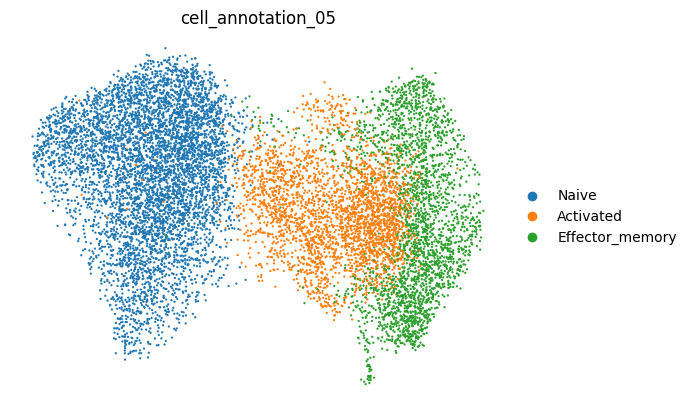

In [6]:
sc.pl.umap(adata, color=cell_group, frameon=False)

## Differential analysis 

### Select conditions to compare

In [8]:
adata.obs.condition.unique() 

['ctrl', 'effector', 'GF']
Categories (3, object): ['GF', 'ctrl', 'effector']

In [9]:
contrasts = [('effector', 'ctrl')]
condition_key = 'condition'

### Filter testable cell types (optional)

In [12]:
control_cells = adata.metabolic_tasks.obs.groupby(['condition', cell_group])['cell_annotation_05'].count().loc['ctrl']
effector_cells = adata.metabolic_tasks.obs.groupby(['condition', cell_group])['cell_annotation_05'].count().loc['effector']

In [13]:
control_cells

cell_annotation_05
Naive              3601
Activated          1445
Effector_memory    1152
Name: cell_annotation_05, dtype: int64

In [14]:
effector_cells

cell_annotation_05
Naive              1765
Activated          1459
Effector_memory    1530
Name: cell_annotation_05, dtype: int64

In [15]:
# Filters
min_n = 50 # Here we do not use a big number as we are only using a subset of the original dataset.
max_log2ratio = 6 # This is 2 power 6 (or 64)

testable_cells = control_cells.index[(control_cells >= min_n) & (effector_cells >= min_n) & (np.log2(control_cells / effector_cells).abs() <= max_log2ratio)].tolist()

In [16]:
testable_cells

['Naive', 'Activated', 'Effector_memory']

### Input for metabolic tasks

In [17]:
input_adata = adata.metabolic_tasks[adata.metabolic_tasks.obs['cell_annotation_05'].isin(testable_cells)]

In [18]:
input_adata

View of AnnData object with n_obs × n_vars = 11351 × 184
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_2', 'rna_leiden_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

### Input for individual reactions

In [22]:
input_adata_reactions = adata.reactions[adata.reactions.obs['cell_annotation_05'].isin(testable_cells)]

In [23]:
input_adata_reactions

View of AnnData object with n_obs × n_vars = 11351 × 623
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts'
    uns: 'Rxn-Max-Genes', 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_2', 'rna_leiden_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

### Perform differential analysis - Metabolic tasks

In [19]:
de_results = sccellfie.stats.scanpy_differential_analysis(input_adata,
                                                          cell_type=None,
                                                          cell_type_key=cell_group,
                                                          condition_key=condition_key,
                                                          min_cells=0, # We do not use this as we already filtered cells before
                                                          condition_pairs=contrasts)

Processing DE analysis: 100%|██████████| 3/3 [00:04<00:00,  1.47s/it]


In [21]:
#de_results.reset_index().to_csv(f'{sc.settings.figdir}/DE-effector-metabolic-tasks.csv')

### Perform differential analysis - Metabolic tasks

In [24]:
de_results_reactions = sccellfie.stats.scanpy_differential_analysis(input_adata_reactions,
                                                          cell_type=None,
                                                          cell_type_key=cell_group,
                                                          condition_key=condition_key,
                                                          min_cells=0, # We do not use this as we already filtered cells before
                                                          condition_pairs=contrasts)

Processing DE analysis: 100%|██████████| 3/3 [00:12<00:00,  4.27s/it]


In [26]:
#de_results_reactions.reset_index().to_csv(f'{sc.settings.figdir}/DE-effector-reactions.csv')

## Results interpretation and visualization

We can use a beeswarm plot, where each row (y-axis) represents the cell types, and the x-axis shows the effect size. Dots are each of the tested features (metabolic tasks), and colored whether they pass both filters, adj. P value and effect size (Cohen’s D here).

In [40]:
cohen_threshold = 0.05 # Min value of absolute Cohen's D.
pval_threshold = 0.01 # Min adj. P value
logfc_threshold = np.log2(1.1) # Min log2FC. Leave it as np.log2(1.) if you do not want to use this filter

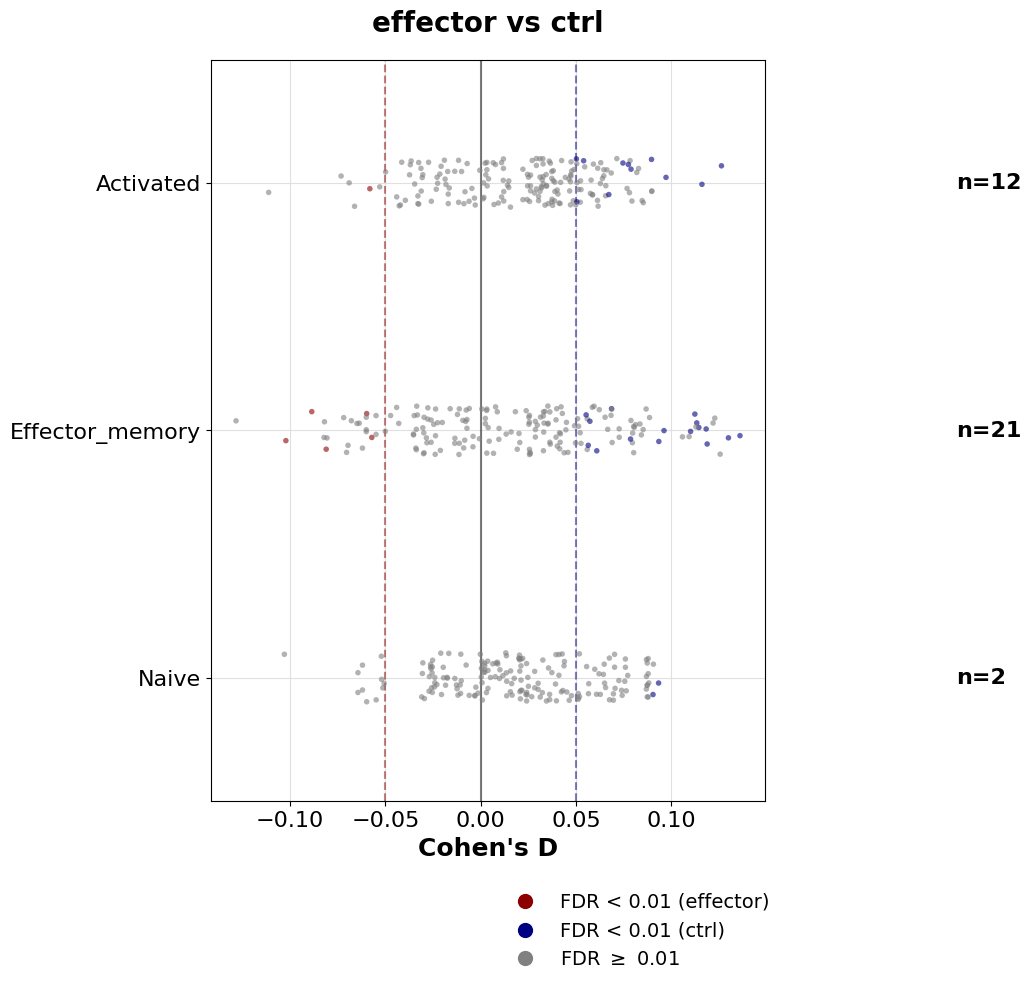

In [41]:
# 1. Update the lambda function to robustly handle labels without prefixes
# If the separator exists, sort by the number; otherwise, sort alphabetically by label name.
sort_lambda = lambda x: pd.Series([
    int(s.split(' | ')[0]) if ' | ' in s else s for s in x
])

fig, ax, sig = sccellfie.plotting.create_beeswarm_plot(
    de_results,
    x='cohens_d',
    cohen_threshold=cohen_threshold,
    pval_threshold=pval_threshold,
    logfc_threshold=logfc_threshold,
    show_n_significant=True, 
    strip_jitter=True,
    sort_lambda=sort_lambda, # Using the safer lambda function
    lgd_bbox_to_anchor=(0.5, -0.1), 
    ticks_fontsize=16,
    labels_fontsize=18,
    figsize=(12, 10)
)

# 2. Force layout generation
fig.canvas.draw()

# 3. Clean up the y-labels cleanly without raising errors
ylabels = [t.get_text() for t in ax.get_yticklabels()]
# Only split if ' | ' is actually present in the text string
cleaned_labels = [label.split(' | ')[1] if ' | ' in label else label for label in ylabels]

# 4. Safely set tick labels back onto the axis
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(cleaned_labels, fontsize=16)
ax.set_ylabel('')

import matplotlib.pyplot as plt
plt.show()


In [43]:
#The number of unique metabolic tasks changing across all cell types:

sig_tasks = sig.reset_index().feature.unique().tolist()
len(sig_tasks)

30

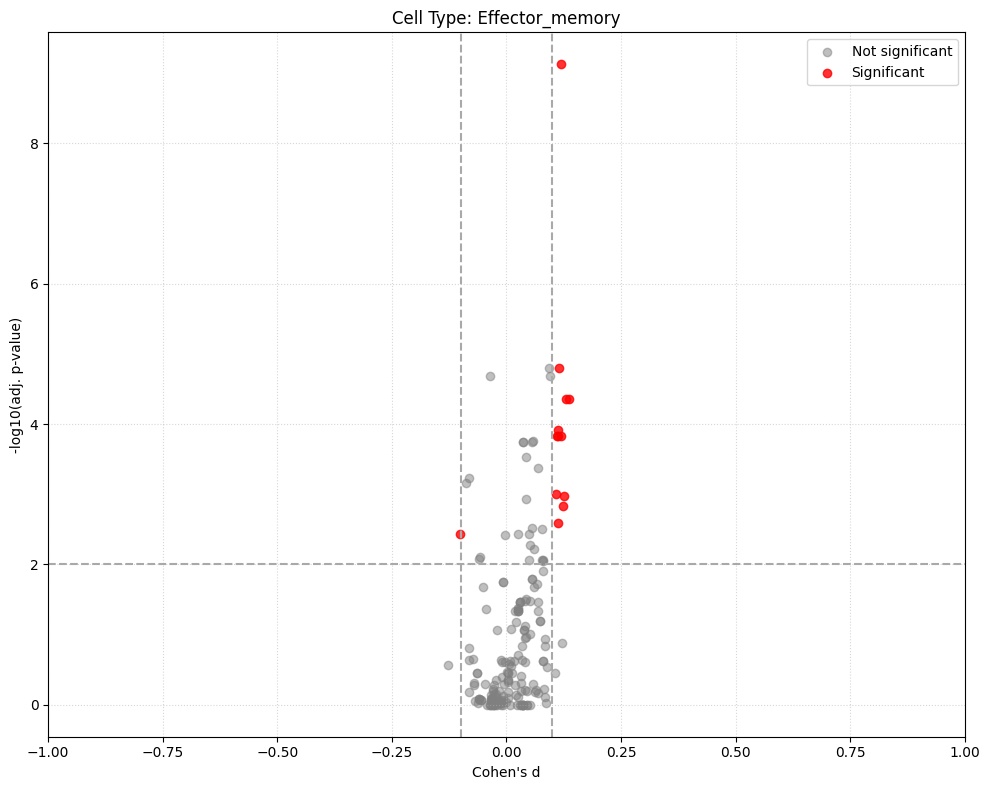

In [82]:
#  volcano plot for one cell type at a time
Effector_tasks = sccellfie.plotting.create_volcano_plot(de_results,
                                                       effect_threshold=0.1,
                                                       padj_threshold=0.01,
                                                       cell_type='Effector_memory',
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [83]:
Effector_tasks

['Synthesis of ubiquinone from tyrosine',
 'Ornithine degradation',
 'Phenylalanine degradation',
 'Tyrosine degradation',
 'Arginine degradation',
 'Alanine degradation',
 'Synthesis of spermidine from ornithine',
 'Cysteine degradation',
 'Trafficking to endosomes (Clathrin Vesicles)',
 'Glutamate degradation',
 'Proline degradation',
 'Valine degradation',
 'Isoleucine degradation']

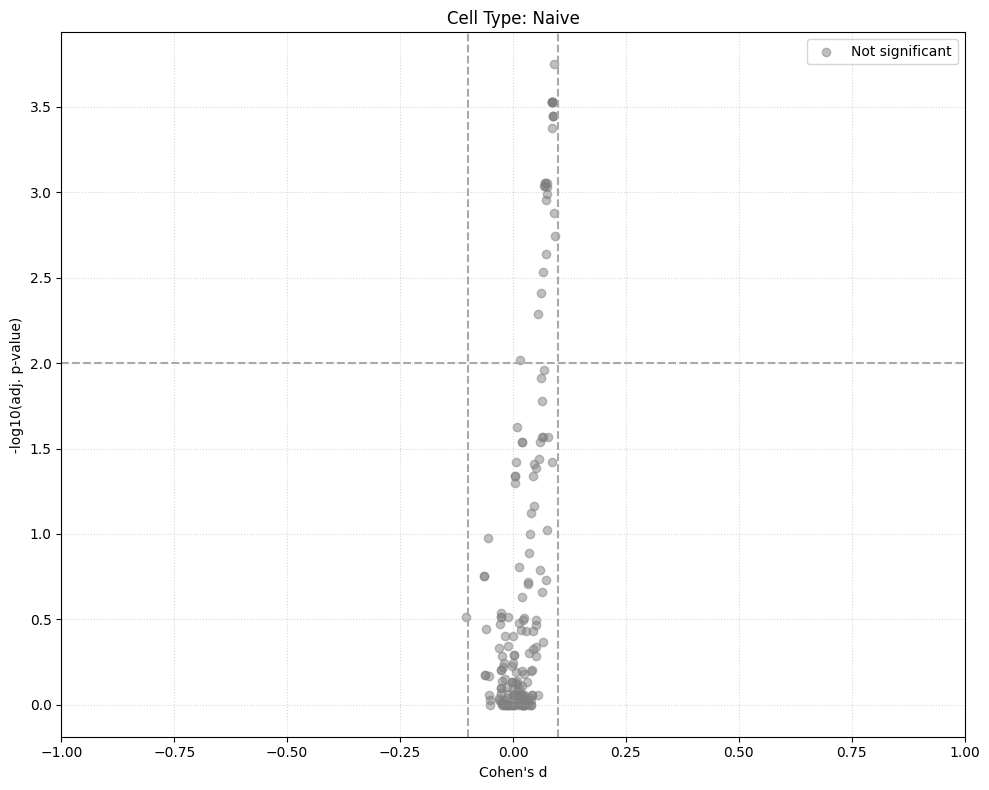

In [101]:
#  volcano plot for one cell type at a time
Naive_tasks = sccellfie.plotting.create_volcano_plot(de_results,
                                                       effect_threshold=0.1,
                                                       padj_threshold=0.01,
                                                       cell_type='Naive',
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [102]:
Naive_tasks

[]

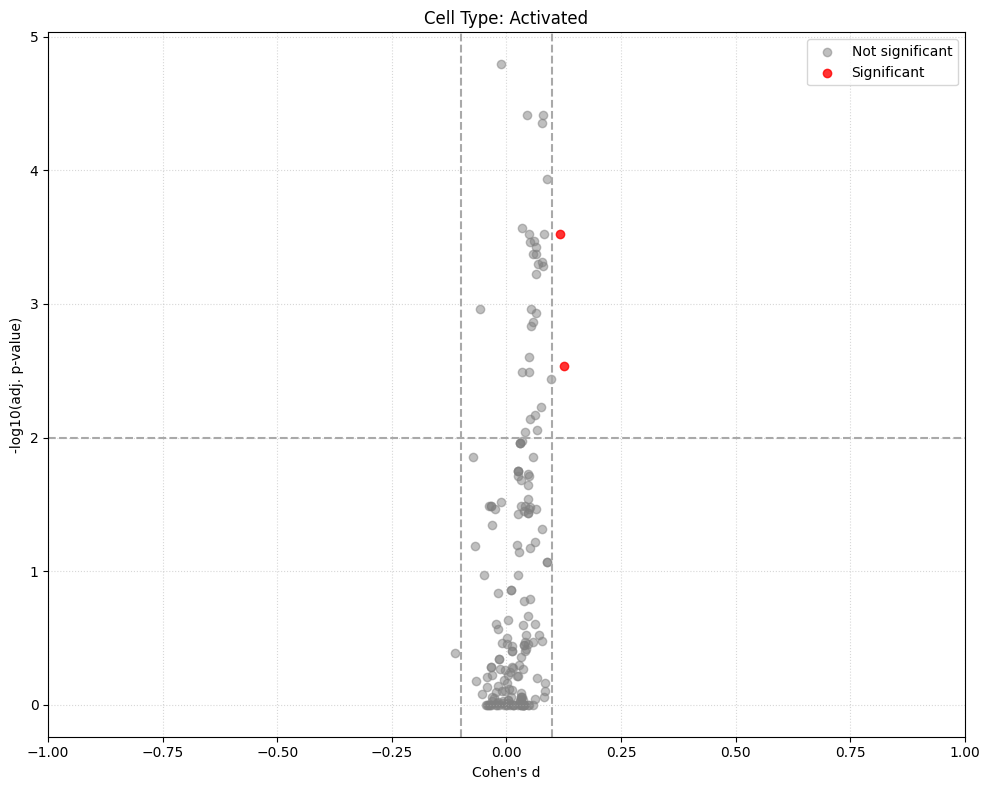

In [103]:
#  volcano plot for one cell type at a time
Activated_tasks = sccellfie.plotting.create_volcano_plot(de_results,
                                                       effect_threshold=0.1,
                                                       padj_threshold=0.01,
                                                       cell_type='Activated',
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [104]:
Activated_tasks

['Glycine degradation', 'Synthesis of spermidine from ornithine']

## Plot number of major task groups up/down regulated

Number of significant tasks given their major categories located in sccellfie_db['task_info']

sccellfie_db = sccellfie.datasets.load_sccellfie_database(organism='mouse')

In [50]:
def plot_single(condition, ax, pathway, sig_data):
    pathway_counts = {'System': pd.DataFrame(), 'Subsystem': pd.DataFrame()}

    for c, df in sig_data.reset_index().groupby('cell_type'):
        for k, v in pathway_counts.items():
            df2 = df.set_index('feature').join(sccellfie_db['task_info'].set_index('Task'), how='inner')
            df2 = df2.loc[df2.log2FC > 0] if condition == 'up' else df2.loc[df2.log2FC < 0]
            df2 = df2.value_counts(k).to_frame().reset_index()
            df2['cell_type'] = c
            df2 = df2[['cell_type', k, 'count']]
            df2[k] = df2[k].apply(lambda x: x.upper())
            pathway_counts[k] = pd.concat([pathway_counts[k], df2])

    df = pathway_counts[pathway].sort_values('count')
    totals = df.groupby('cell_type')['count'].sum()

    df_normalized = df.copy()
    df_normalized['fraction'] = df.groupby('cell_type')['count'].transform(lambda x: x / x.sum())
    pivoted_data = df_normalized.pivot(index='cell_type', columns=pathway, values='fraction')
    pivoted_data = pivoted_data.sort_index().fillna(0.)

    n_systems = len(pivoted_data.columns)
    colors = glasbey.extend_palette('Set2', palette_size=max([n_systems, 10]))

    pivoted_data.plot(kind='barh', stacked=True, ax=ax, color=colors, legend=False)
    ax.set_xlim((0, 1))
    ax.invert_yaxis()

    ylabels = ax.get_yticklabels()
    ax.tick_params(axis='both', which='major', labelsize=12)

    for idx, cell_type in enumerate(pivoted_data.index):
        ax.text(1.02, idx, f'n={totals[cell_type]:,}', va='center', fontsize=12)

    ax.set_xlabel('Fraction', fontsize=14)
    ax.set_ylabel('')

    return pivoted_data.columns, colors

In [ ]:
sig

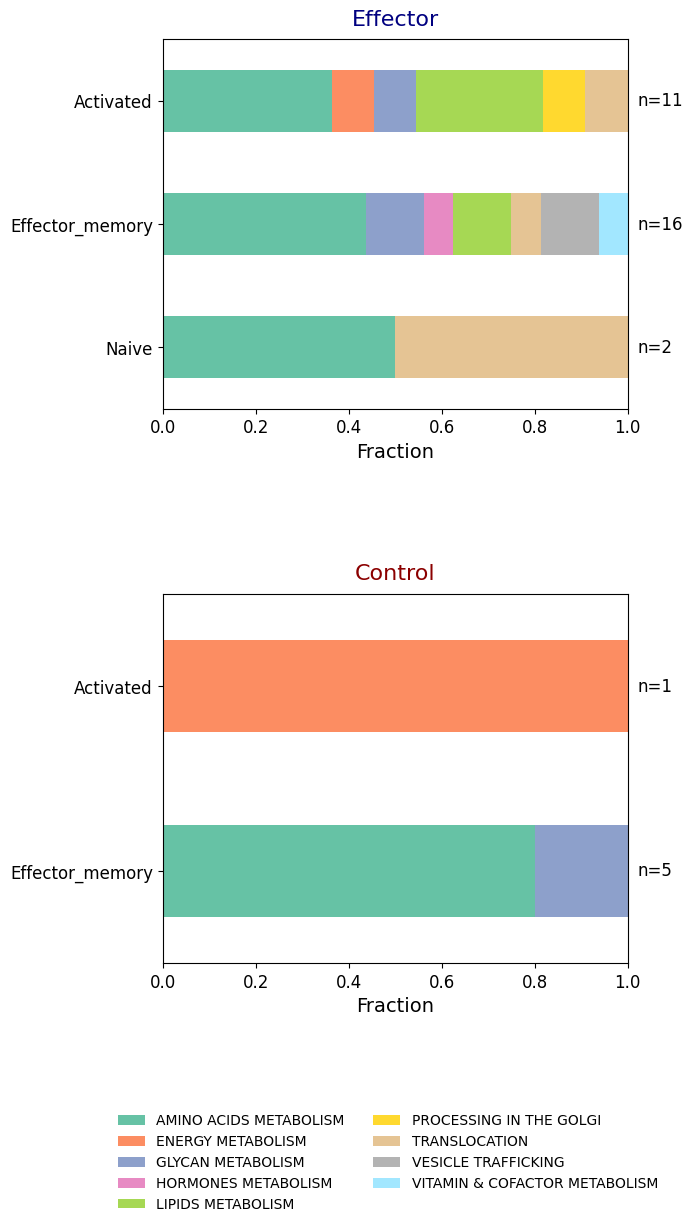

In [51]:
from matplotlib.colors import to_rgb

pathway = 'System'
condition1_color='#8B0000'
condition2_color='#000080'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12), height_ratios=[1, 1])

legend_elements, colors = plot_single('up', ax1, pathway, sig)
plot_single('down', ax2, pathway, sig)

ax1.set_title('Effector', fontsize=16, pad=10, color=to_rgb(condition2_color))
ax2.set_title('Control', fontsize=16, pad=10, color=to_rgb(condition1_color))

plt.figlegend(labels=legend_elements,
              bbox_to_anchor=(0.5, -0.005),
              ncols=2 if pathway == 'System' else 2,
              frameon=False,
              loc='upper center')

plt.subplots_adjust(hspace=0.5)
# For saving this figure, uncomment the code below
# plt.savefig(f'{sc.settings.figdir}./scCellFie-DA-{pathway}-Combined.pdf',
#             dpi=300,
#             bbox_inches='tight')

## Visualize changes in distributions across single cells

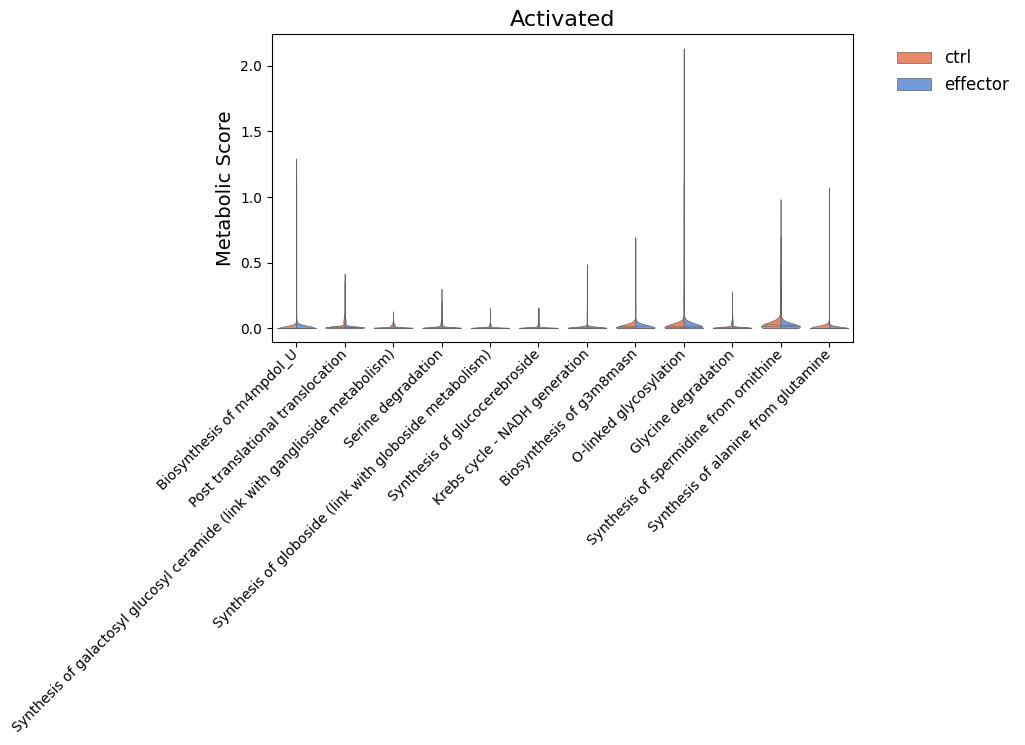

In [58]:
import matplotlib.pyplot as plt

cell_show = ['Activated']

for c in cell_show:
    sig_features = [idx for idx in sig.loc[c].sort_values('log2FC').index]
    N = len(sig_features)
    if N > 0:
        width = min([18, 1.5 + 0.5 * N])
        fig, ax = sccellfie.plotting.create_comparative_violin(
            adata=adata.metabolic_tasks,
            significant_features=sig_features,
            group1='ctrl',
            group2='effector',
            condition_key=condition_key,
            cell_type_key=cell_group,
            celltype=c,
            xlabel='',
            ylabel='Metabolic Score',
            palette=['coral', 'cornflowerblue'],
            wrapped_title_length=100,
            figsize=(width, 4),
            fontsize=14,
            title=c,
            tight_layout=False,
            # save=f'DE-Dist-{cname}'
        )
        
        # --- Rotate x-axis labels 45 degrees ---
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Ensure rotated labels don't get cut off at the bottom
        fig.tight_layout()
        
        plt.show()

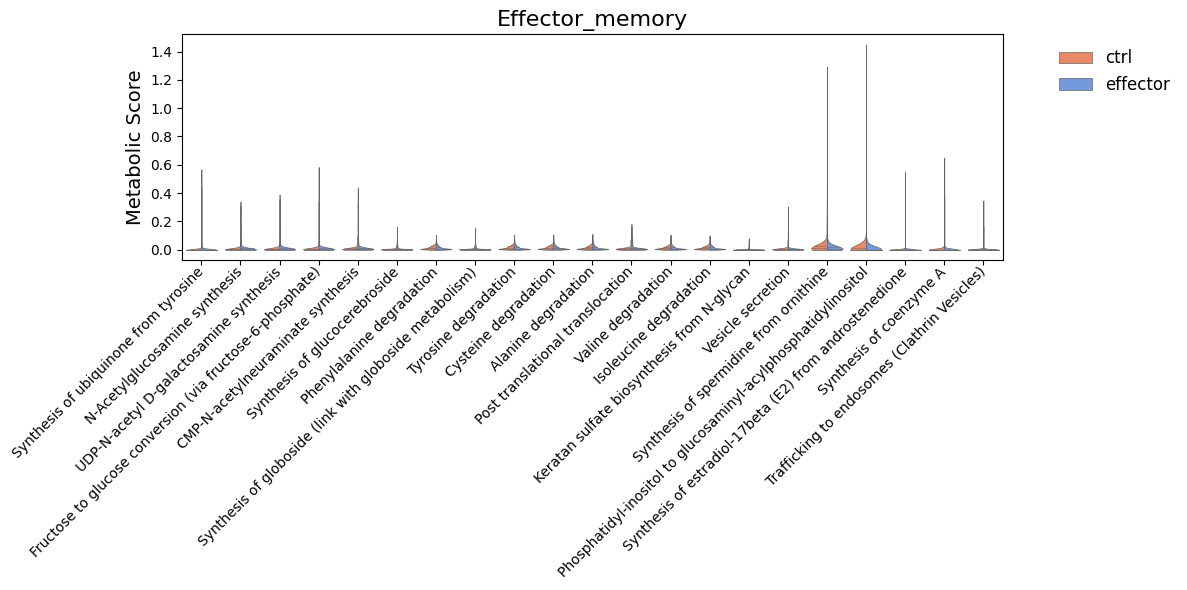

In [63]:
import matplotlib.pyplot as plt

cell_show = ['Effector_memory']

for c in cell_show:
    sig_features = [idx for idx in sig.loc[c].sort_values('log2FC').index]
    N = len(sig_features)
    if N > 0:
        width = min([18, 1.5 + 0.5 * N])
        fig, ax = sccellfie.plotting.create_comparative_violin(
            adata=adata.metabolic_tasks,
            significant_features=sig_features,
            group1='ctrl',
            group2='effector',
            condition_key=condition_key,
            cell_type_key=cell_group,
            celltype=c,
            xlabel='',
            ylabel='Metabolic Score',
            palette=['coral', 'cornflowerblue'],
            wrapped_title_length=100,
            figsize=(width, 6),
            fontsize=14,
            title=c,
            tight_layout=False,
            # save=f'DE-Dist-{cname}'
        )
        
        # --- Rotate x-axis labels 45 degrees ---
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Ensure rotated labels don't get cut off at the bottom
        fig.tight_layout()
        
        plt.show()

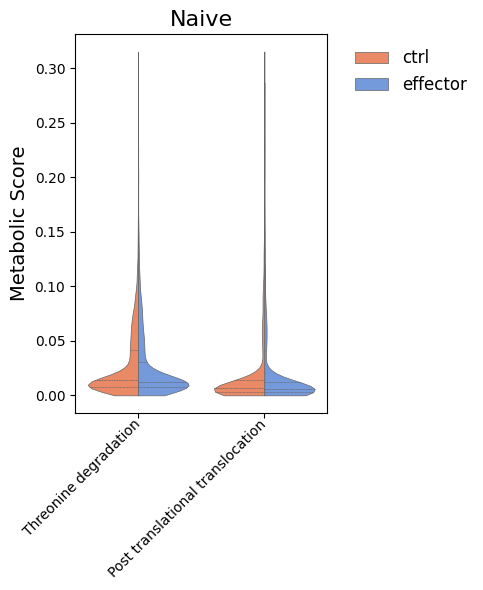

In [66]:
import matplotlib.pyplot as plt

cell_show = ['Naive']

for c in cell_show:
    sig_features = [idx for idx in sig.loc[c].sort_values('log2FC').index]
    N = len(sig_features)
    if N > 0:
        width = min([18, 1.5 + 0.5 * N])
        fig, ax = sccellfie.plotting.create_comparative_violin(
            adata=adata.metabolic_tasks,
            significant_features=sig_features,
            group1='ctrl',
            group2='effector',
            condition_key=condition_key,
            cell_type_key=cell_group,
            celltype=c,
            xlabel='',
            ylabel='Metabolic Score',
            palette=['coral', 'cornflowerblue'],
            wrapped_title_length=100,
            figsize=(5, 6),
            fontsize=14,
            title=c,
            tight_layout=False,
            # save=f'DE-Dist-{cname}'
        )
        
        # --- Rotate x-axis labels 45 degrees ---
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Ensure rotated labels don't get cut off at the bottom
        fig.tight_layout()
        
        plt.show()

## Differential analysis - using all single cells.

In [54]:
da_all = sccellfie.stats.pairwise_differential_analysis(adata.metabolic_tasks,
                                                        groupby='condition', # Column including the conditions
                                                        var_names=None,
                                                        order=None,
                                                        alternative='two-sided',
                                                        alpha=0.05)

Processing features: 100%|██████████| 184/184 [00:00<00:00, 238.96it/s]


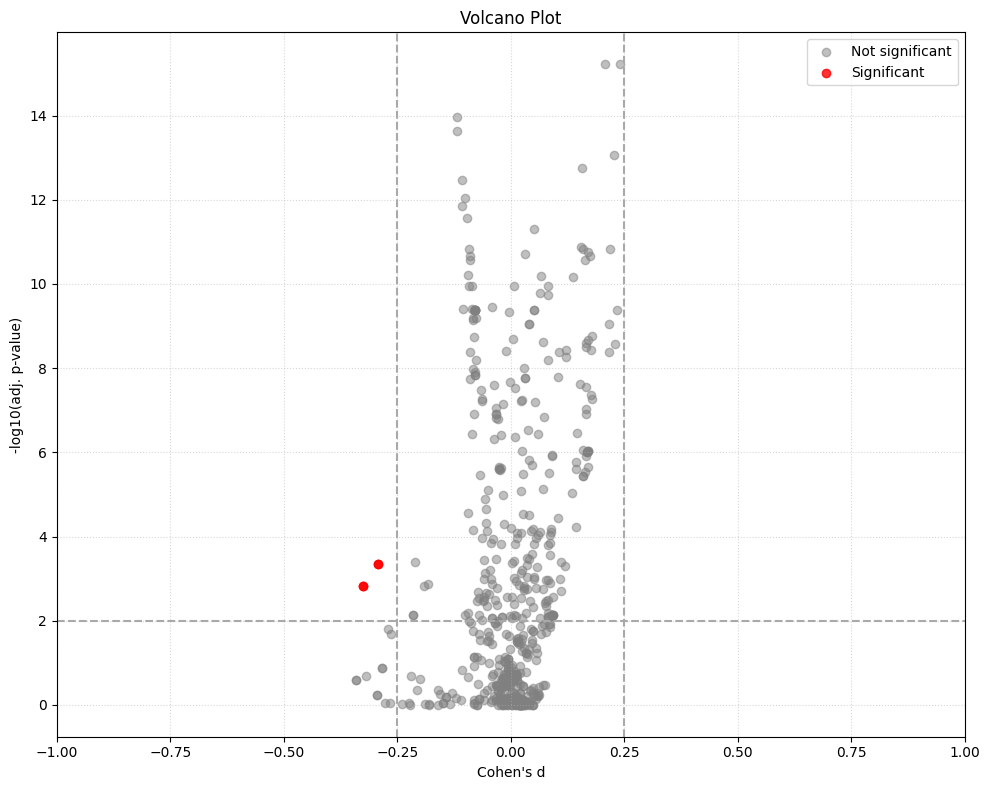

In [67]:
overall_tasks = sccellfie.plotting.create_volcano_plot(da_all,
                                                       effect_threshold=0.25,
                                                       padj_threshold=0.01,
                                                       cell_type=None,
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [68]:
overall_tasks

['Glucuronate synthesis (via inositol)', 'Synthesis of inositol']